In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline, PchipInterpolator, UnivariateSpline, Akima1DInterpolator
from matplotlib import pyplot as plt
import pprint as pprint
#import papermill as pm
import scrapbook as sb
from Utils import ReadTheCsv,ReadTheSpill,append_to_dict

class bcolors:
    OK = "\033[92m"  # GREEN
    WARNING = "\033[93m"  # YELLOW
    FAIL = "\033[91m"  # RED
    RESET = "\033[0m"  # RESET COLOR

In [2]:
!pip install scrapbook
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
CutsType = "CutsType2"
run_to_analyze = "ag14314/ag14314.vertex.csv"
bkg_up = 0.0010
bkg_down = 0.0008

In [4]:
runs = {"2025": [run_to_analyze]}

mirG_center = -415 # <----
mirA_center = -671 # <----
zmin = mirA_center - 200 # <----
zgap_min = mirA_center # <----
zmax = mirG_center + 200 # <----
zgap_max = mirG_center # <----

class Zcuts:
    def __init__(self,a,b):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a

ZCUTS = Zcuts(-415,-671)

# estimate background

In [5]:
if(True): # < ----
    datacosm = ReadTheCsv("ag13628/ag13628.vertex.csv",  "-1", zmin, zmax, CutsType)
    mask_down = (datacosm["Z"] < zgap_min)
    bkg_down = (mask_down.sum())/6668
    mask_up = (datacosm["Z"] > zgap_max)
    bkg_up = (mask_up.sum())/6668
    print(f"Bkg estimated: up region {bkg_up:.4f} Hz down region {bkg_down:.4f} Hz")

Bkg estimated: up region 0.0010 Hz down region 0.0009 Hz


In [6]:
data = ReadTheCsv(runs["2025"][0],  "-1", zmin, zmax, CutsType)

# Microwave DUMP
mw_cb_start, mw_cb_stop = ReadTheSpill(runs["2025"][0], "\"Microwave Dump\"[0]")

# First round laser Cooling
#first_LC_start, first_LC_stop = ReadTheSpill2(runs["2025"][0],"Lyman Alpha") # Work In Progress

# Second Round Laser Cooling
#second_LC_start, second_LC_stop = ReadTheSpill2(runs["2025"][0],"\"Adiabatic Expansion\"[0]") # Work in Progress

# PreGravityWell
pregravity_start, pregravity_stop = ReadTheSpill(runs["2025"][0], "\"PreGravityWell\"[0]")

# Initial OcB Ramp Down
InitOcB_start, InitOcB_stop = ReadTheSpill(runs["2025"][0], "\"Initial OcB Ramp Down\"[0]")

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill(runs["2025"][0], "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill(runs["2025"][0], "\"WaitForQuasitrapped\"[1]")
waitForQuasiTrapped_start2, waitForQuasiTrapped_stop2 = ReadTheSpill(runs["2025"][0], "\"WaitForQuasitrapped\"[2]")

# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(runs["2025"][0],"\"MBMF RampDown\"[0]")
start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill(runs["2025"][0],"\"MBMF RampDown\"[1]")
start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill(runs["2025"][0],"\"MBMF RampDown\"[2]")
start_mbmf_rampdown3, stop_mbmf_rampdown3 = ReadTheSpill(runs["2025"][0],"\"MBMF RampDown\"[3]")

# Oc RampDown
Oc_start_rampdown, Oc_stop_rampdown = ReadTheSpill(runs["2025"][0],"\"Oc RampDown\"[0]")

# Porch
start_RampAllFinalStep, stop_RampAllFinalStep = ReadTheSpill(runs["2025"][0],"\"RampAllFinalStep\"[0]")

print(mw_cb_start)

ag14314/ag14314.vertex.csv
   [ 773.755-2309.783]=1536.027s |          "Microwave Dump"[0]         |  189382     8484     8462     5765    84790    64816   200527   124453   335959      2983 

ag14314/ag14314.vertex.csv
   [23061.962-23163.065]= 101.103s |          "PreGravityWell"[0]         |   10969      556      551      394     5778     4310    13258     8326    22795       215 

ag14314/ag14314.vertex.csv
   [23183.266-23284.369]= 101.103s |          "Initial OcB Ramp Down"[0]  |   11094      599      522      399     5780     4309    13706     8459    23190       211 

ag14314/ag14314.vertex.csv
   [23304.850-23404.853]= 100.003s |          "WaitForQuasitrapped"[0]    |   11032      543      531      384     5644     4064    12795     7655    21575        75 

ag14314/ag14314.vertex.csv
   [23913.553-24513.560]= 600.008s |          "WaitForQuasitrapped"[1]    |   64704     3258     3156     2253    33200    24700    75241    46132   128083       374 

ag14314/ag14314.vertex.csv


# Time Summary Plot

[300]
0.020124525094981364
10.322333333333518
bin time 10.322333333333518
[   32.81467168   189.17714797 23761.90323479]


/tmp/ipykernel_50948/2864074045.py:25: RuntimeWarning: overflow encountered in exp
  return N * np.exp(-(x - t0)/tau)


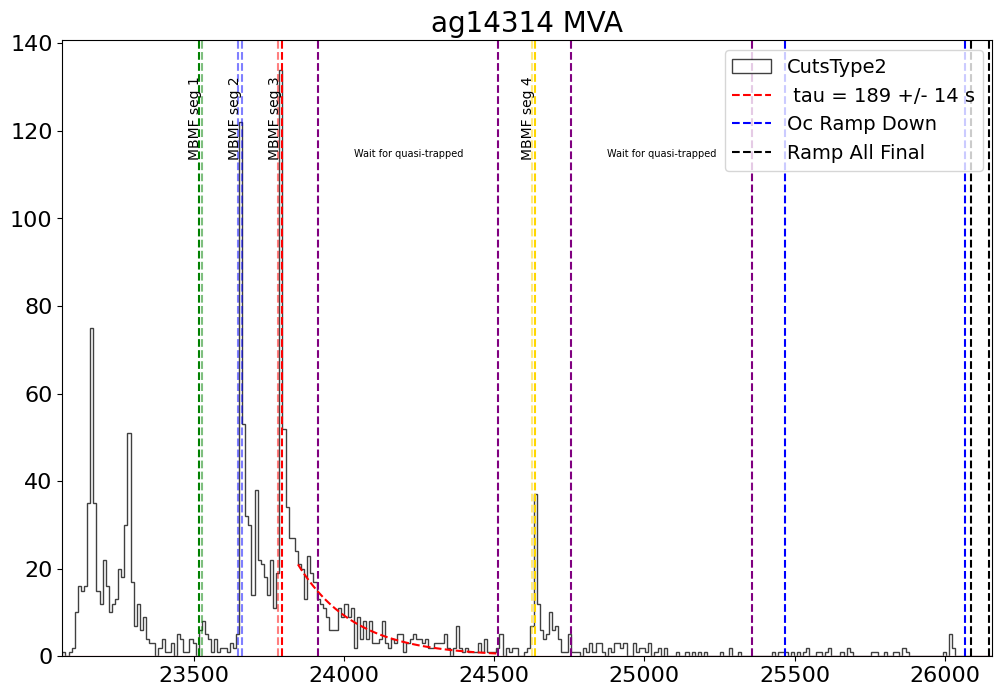

In [21]:
binning = np.array([300])
print(binning)

plt.figure(0, figsize = (12, 8))
plt.title(f"ag{runs['2025'][0].split('/')[0].replace('ag','')} MVA", fontsize = 20)
plt.yticks(fontsize = 16)
plt.xticks(fontsize = 16)
#plt.ylim(0,30)
plt.xlim(pregravity_start[0], stop_RampAllFinalStep[0] + 10)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (pregravity_start[0], stop_RampAllFinalStep[0] + 10) , histtype = "step", color = "black", density = False, label = f"{CutsType}", alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

#### FIT BOIL UP DATA
edges = edges[0:-1] + np.diff(edges)[0]
mask_fit = (edges > stop_mbmf_rampdown2[0] + 50) & (edges < waitForQuasiTrapped_stop1[0] )
def exponential(x, N, tau, t0):
    return N * np.exp(-(x - t0)/tau)

popt, pcovm = curve_fit(exponential, edges[mask_fit],  TOT_RUN_counts[mask_fit], p0 = [100, 20, stop_mbmf_rampdown2[0]])

errorttau = np.sqrt(pcovm.diagonal()[1])
print(popt)

try:
    plt.plot(edges[mask_fit], exponential(edges[mask_fit], *popt), marker = '', color = 'red', linestyle = "--", label = f" tau = {int(popt[1])} +/- {int(errorttau)} s")
except:
    print("something wrong")

plt.axvline(waitForQuasiTrapped_start1[0], linestyle = "--", color = "purple")
plt.axvline(waitForQuasiTrapped_stop1[0],  linestyle = "--", color = "purple")
plt.axvline(waitForQuasiTrapped_start2[0], linestyle = "--", color = "purple")
plt.axvline(waitForQuasiTrapped_stop2[0],  linestyle = "--", color = "purple")
plt.text((waitForQuasiTrapped_start1[0] + waitForQuasiTrapped_stop1[0])/2 - 180, maxbin - 20, "Wait for quasi-trapped", fontsize = 7)
plt.text((waitForQuasiTrapped_start2[0] + waitForQuasiTrapped_stop2[0])/2 - 180, maxbin - 20, "Wait for quasi-trapped", fontsize = 7)

plt.axvline(start_mbmf_rampdown0[0], linestyle = "--", color = "green")
plt.axvline(stop_mbmf_rampdown0[0],  linestyle = "--", color = "green", alpha = 0.5)
plt.text(start_mbmf_rampdown0[0] - 35, maxbin - 20, "MBMF seg 1",rotation = 90)

plt.axvline(start_mbmf_rampdown1[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown1[0],  linestyle = "--", color = "blue", alpha = 0.5)
plt.text(start_mbmf_rampdown1[0] - 35, maxbin - 20, "MBMF seg 2",rotation = 90)

plt.axvline(start_mbmf_rampdown2[0], linestyle = "--", color = "red", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown2[0],  linestyle = "--", label = "", color = "red")
plt.text(start_mbmf_rampdown2[0] - 35, maxbin - 20, "MBMF seg 3",rotation = 90)

plt.axvline(start_mbmf_rampdown3[0], linestyle = "--", color = "gold", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown3[0],  linestyle = "--", label = "", color = "gold")
plt.text(start_mbmf_rampdown3[0] - 35, maxbin - 20, "MBMF seg 4",rotation = 90)

plt.axvline(Oc_start_rampdown[0], linestyle = "--", label = "Oc Ramp Down", color = "blue")
plt.axvline(Oc_stop_rampdown[0],  linestyle = "--", label = "", color = "blue")

plt.axvline(start_RampAllFinalStep[0], linestyle = "--", label = "Ramp All Final", color = "black")
plt.axvline(stop_RampAllFinalStep[0],  linestyle = "--", label = "", color = "black")

#plt.ylim(0,30)

plt.legend( fontsize = 14, loc = "upper right")
plt.savefig(f"figures/Summary_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

## Time distributions during segments

[40]
0.0009846505698855462
0.5050499999997555
bin time 0.5050499999997555
0.0009846993101398109
0.505075000000943
bin time 0.505075000000943
0.0009846505698855462
0.5050499999997555
bin time 0.5050499999997555


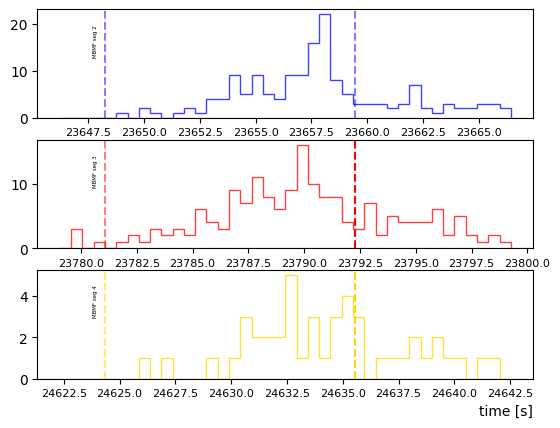

In [23]:
binning = np.array([40])
print(binning)

plt.figure(1)
# plt.subplot(3,1,1)
# plt.title(f"ag{runs['2025'][0].split('/')[0].replace('ag','')} MVA", fontsize = 20)
# #plt.yticks(fontsize = 16)
# #plt.xticks(fontsize = 16)
# #plt.ylim(0,30)
# TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (start_mbmf_rampdown0[0] - 2, stop_mbmf_rampdown0[0] + 7) , histtype = "step", color = "green", density = False, alpha = 0.75)
# maxbin = np.max(TOT_RUN_counts)

# plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
# print((bkg_up + bkg_down) * np.diff(edges)[0])
# print(np.diff(edges)[0])

# time_bin = np.diff(edges)[0]
# print("bin time", time_bin)

# plt.axvline(start_mbmf_rampdown0[0], linestyle = "--", color = "green")
# plt.axvline(stop_mbmf_rampdown0[0], linestyle = "--", color = "green", alpha = 0.5)
# plt.text(start_mbmf_rampdown0[0] - .5, 0.6*maxbin, "MBMF seg 1",rotation = 90, fontsize = 9)
# #plt.legend()

plt.subplot(3,1,1)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (start_mbmf_rampdown1[0] - 2, stop_mbmf_rampdown1[0] + 7) , histtype = "step", color = "blue", density = False, alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

plt.axvline(start_mbmf_rampdown1[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown1[0], linestyle = "--", color = "blue", alpha = 0.5)
plt.text(start_mbmf_rampdown1[0] - .5, 0.6* maxbin, "MBMF seg 2",rotation = 90, fontsize = 4)
plt.xticks(fontsize = 8)

plt.subplot(3,1,2)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (start_mbmf_rampdown2[0] - 2, stop_mbmf_rampdown2[0] + 7) , histtype = "step", color = "red", density = False, alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

plt.axvline(start_mbmf_rampdown2[0], linestyle = "--", color = "red", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown2[0], linestyle = "--", label = "", color = "red")
plt.text(start_mbmf_rampdown2[0] - 0.5, 0.6*maxbin, "MBMF seg 3",rotation = 90, fontsize = 4)
plt.xlabel("time [s]", loc = "right")
plt.xticks(fontsize = 8)

plt.subplot(3,1,3)

TOT_RUN_counts, edges, trash = plt.hist(data["run time"], bins = binning[0], range =  (start_mbmf_rampdown3[0] - 2, stop_mbmf_rampdown3[0] + 7) , histtype = "step", color = "gold", density = False, alpha = 0.75)
maxbin = np.max(TOT_RUN_counts)

plt.axhline((bkg_up + bkg_down) * np.diff(edges)[0], linestyle = "-", linewidth = 1, color = "pink")
print((bkg_up + bkg_down) * np.diff(edges)[0])
print(np.diff(edges)[0])

time_bin = np.diff(edges)[0]
print("bin time", time_bin)

plt.axvline(start_mbmf_rampdown3[0], linestyle = "--", color = "gold", alpha = 0.5)
plt.axvline(stop_mbmf_rampdown3[0], linestyle = "--", label = "", color = "gold")
plt.text(start_mbmf_rampdown3[0] - 0.5, 0.6*maxbin, "MBMF seg 4",rotation = 90, fontsize = 4)
plt.xlabel("time [s]", loc = "right")
plt.xticks(fontsize = 8)

plt.savefig(f"figures/Ramps_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Mirror B and F three segments + QuasiTrapped

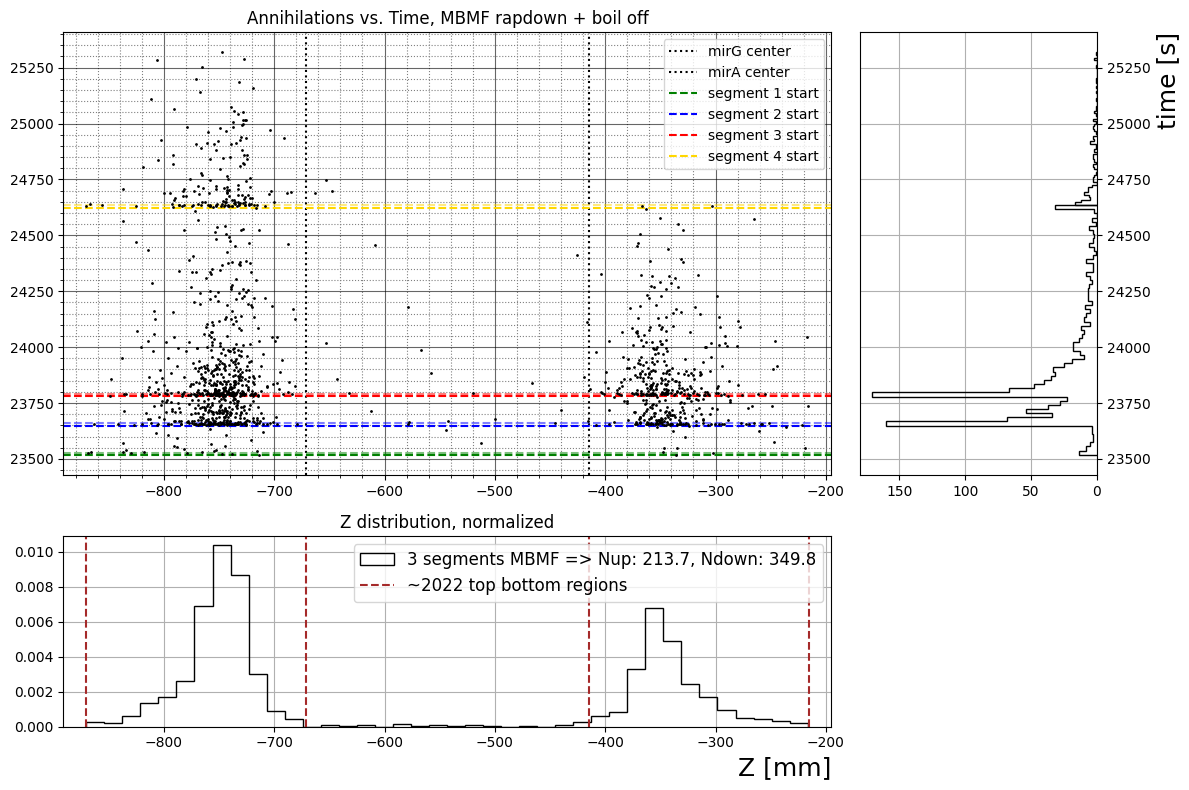

In [25]:
def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):
    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zmin) & (data["Z"] < zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zgap_max) & (data["Z"] < zmax)
    return Nup.sum(), Ndwn.sum()

mask   = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < stop_mbmf_rampdown3[0])
mask2 = (data["run time"] > stop_mbmf_rampdown3[0])  & (data["run time"] < waitForQuasiTrapped_stop2[0])

Nup, Ndown = NupNdown(data, start_mbmf_rampdown0[0], stop_mbmf_rampdown2[0], zmin, zmax, zgap_min, zgap_max)

Nup   -= bkg_up   * (stop_mbmf_rampdown2[0] - start_mbmf_rampdown0[0])
Ndown -= bkg_down * (stop_mbmf_rampdown2[0] - start_mbmf_rampdown0[0])

S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "black", marker = ".", linestyle = "", markersize = 2)
ax1.errorbar(data["Z"][mask2], data["run time"][mask2] , color = "black", marker = ".", linestyle = "", markersize = 2)
ax1.axvline(mirG_center, linestyle = "dotted", color = "black", label = "mirG center")
ax1.axvline(mirA_center, linestyle = "dotted", color = "black", label = "mirA center")
ax1.axhline(start_mbmf_rampdown0[0], linestyle = "--", label = "segment 1 start", color = "green")
ax1.axhline(stop_mbmf_rampdown0[0],  linestyle = "--", color = "green", alpha = 0.5)
ax1.axhline(start_mbmf_rampdown1[0], linestyle = "--", label = "segment 2 start", color = "blue")
ax1.axhline(stop_mbmf_rampdown1[0],  linestyle = "--", color = "blue", alpha = 0.5)
ax1.axhline(start_mbmf_rampdown2[0], linestyle = "--", label = "segment 3 start", color = "red")
ax1.axhline(stop_mbmf_rampdown2[0],  linestyle = "--", color = "red", alpha = 0.5)
ax1.axhline(start_mbmf_rampdown3[0], linestyle = "--", label = "segment 4 start", color = "gold")
ax1.axhline(stop_mbmf_rampdown3[0],  linestyle = "--", color = "gold", alpha = 0.5)

ax1.set_title("Annihilations vs. Time, MBMF rapdown + boil off")
ax1.set_xlim(zmin-20,zmax+20)
ax1.legend()
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"3 segments MBMF => Nup: {Nup:.1f}, Ndown: {Ndown:.1f}")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)
ax2.grid()

counts, bins, _ = ax3.hist(data["run time"][mask],  bins = 60, histtype = "step", color = "black", density = False, orientation='horizontal')
counts, bins, _ = ax3.hist(data["run time"][mask2], bins = 60, histtype = "step", color = "black", density = False, orientation='horizontal')
xgrid = np.linspace(bins[4], bins[-1], 100)

#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()
ax3.grid()

plt.tight_layout()
plt.show()
fig.savefig(f"figures/MBMF_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Z pdf for the three segments

## Z Only segments

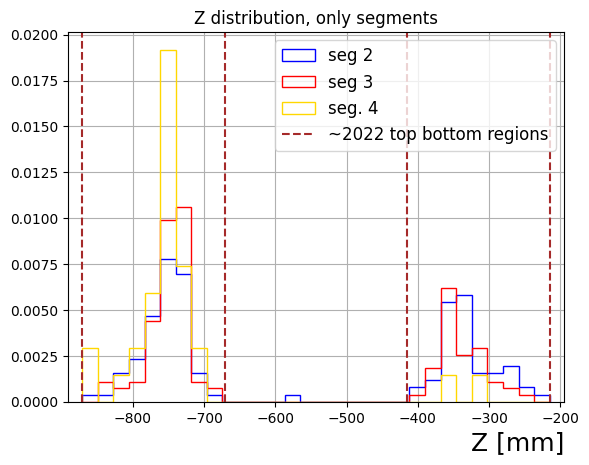

In [26]:
ax = plt.subplot(1,1,1)  # occuopa 3 righe

mask_seg0   = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < stop_mbmf_rampdown0[0])
mask_seg1   = (data["run time"] > start_mbmf_rampdown1[0]) & (data["run time"] < stop_mbmf_rampdown1[0])
mask_seg2   = (data["run time"] > start_mbmf_rampdown2[0]) & (data["run time"] < stop_mbmf_rampdown2[0])
mask_seg3   = (data["run time"] > start_mbmf_rampdown3[0]) & (data["run time"] < stop_mbmf_rampdown3[0])

#print(stop_mbmf_rampdown0[0],start_mbmf_rampdown1[0] )

ax.set_title("Z distribution, only segments")
ax.set_xlabel("Z [mm]", loc = "right", fontsize = 18)

# ax.hist(data["Z"][mask_seg0], 
#         bins = 30, 
#         range = [zmin, zmax],
#         histtype = "step", 
#         color = "green", 
#         density = True,  
#         label = f"seg 1")

ax.hist(data["Z"][mask_seg1], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "blue", 
        density = True,  
        label = f"seg 2")

ax.hist(data["Z"][mask_seg2], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "red", 
        density = True,  
        label = f"seg 3")

ax.hist(data["Z"][mask_seg3], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "gold", 
        density = True,  
        label = f"seg. 4")


ax.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax.axvline(zmax,linestyle = "--", color = "brown")
ax.axvline(zgap_min,linestyle = "--", color = "brown")
ax.axvline(zgap_max,linestyle = "--", color = "brown")
ax.set_xlim(zmin-20,zmax+20)
ax.legend(fontsize = 12)
ax.grid()
plt.savefig(f"figures/Zpds_three_segments_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

## segments + wait

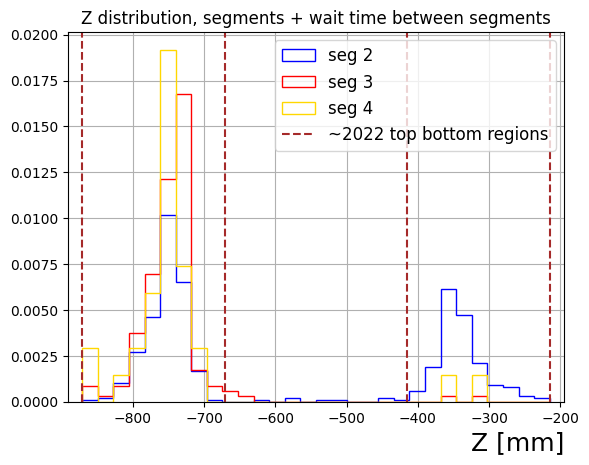

In [27]:
ax = plt.subplot(1,1,1)  # occuopa 3 righe

mask_seg0   = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < start_mbmf_rampdown1[0])
mask_seg1   = (data["run time"] > start_mbmf_rampdown1[0]) & (data["run time"] < start_mbmf_rampdown2[0])
mask_seg2   = (data["run time"] > start_mbmf_rampdown2[0]) & (data["run time"] < start_mbmf_rampdown2[0] + 600)
mask_seg2   = (data["run time"] > start_mbmf_rampdown3[0]) & (data["run time"] < stop_mbmf_rampdown3[0] + 600)

ax.set_title("Z distribution, segments + wait time between segments")
ax.set_xlabel("Z [mm]", loc = "right", fontsize = 18)

ax.hist(data["Z"][mask_seg1], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "blue", 
        density = True,  
        label = f"seg 2")

ax.hist(data["Z"][mask_seg2], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "red", 
        density = True,  
        label = f"seg 3")

ax.hist(data["Z"][mask_seg3], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "gold", 
        density = True,  
        label = f"seg 4")

ax.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax.axvline(zmax,linestyle = "--", color = "brown")
ax.axvline(zgap_min,linestyle = "--", color = "brown")
ax.axvline(zgap_max,linestyle = "--", color = "brown")
ax.set_xlim(zmin-20,zmax+20)
ax.legend(fontsize = 12)
ax.grid()
plt.savefig(f"figures/Zpds_threesegmentsAndWait_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

## Only wait in between segments

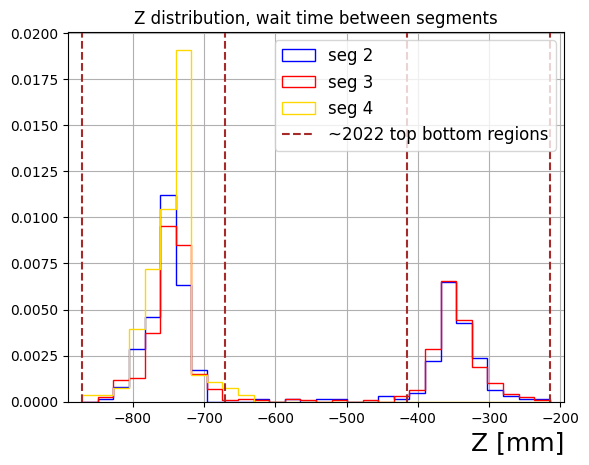

In [12]:
ax = plt.subplot(1,1,1)  # occuopa 3 righe

mask_seg0   = (data["run time"] > stop_mbmf_rampdown0[0]) & (data["run time"] < start_mbmf_rampdown1[0])
mask_seg1   = (data["run time"] > stop_mbmf_rampdown1[0]) & (data["run time"] < start_mbmf_rampdown2[0])
mask_seg2   = (data["run time"] > stop_mbmf_rampdown2[0]) & (data["run time"] < start_mbmf_rampdown3[0])
mask_seg3   = (data["run time"] > stop_mbmf_rampdown3[0]) & (data["run time"] < stop_mbmf_rampdown3[0] + 600)

ax.set_title("Z distribution, wait time between segments")
ax.set_xlabel("Z [mm]", loc = "right", fontsize = 18)

ax.hist(data["Z"][mask_seg1], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "blue", 
        density = True,  
        label = f"seg 2")

ax.hist(data["Z"][mask_seg2], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "red", 
        density = True,  
        label = f"seg 3")

ax.hist(data["Z"][mask_seg3], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "gold", 
        density = True,  
        label = f"seg 4")

ax.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax.axvline(zmax,linestyle = "--", color = "brown")
ax.axvline(zgap_min,linestyle = "--", color = "brown")
ax.axvline(zgap_max,linestyle = "--", color = "brown")
ax.set_xlim(zmin-20,zmax+20)
ax.legend(fontsize = 12)
ax.grid()
plt.savefig(f"figures/Zpds_threesegmentsWait_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

## Boiling atoms

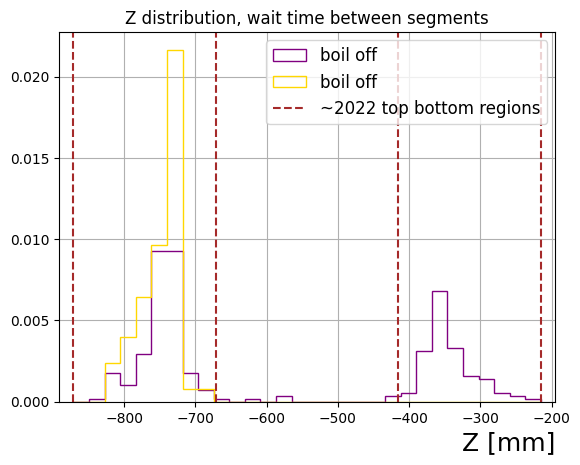

In [13]:
ax = plt.subplot(1,1,1)  # occuopa 3 righe

mask_seg0   = (data["run time"] > waitForQuasiTrapped_start1[0]) & (data["run time"] < waitForQuasiTrapped_stop1[0])
mask_seg1   = (data["run time"] > waitForQuasiTrapped_start2[0]) & (data["run time"] < waitForQuasiTrapped_stop2[0])

ax.set_title("Z distribution, wait time between segments")
ax.set_xlabel("Z [mm]", loc = "right", fontsize = 18)

ax.hist(data["Z"][mask_seg0], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "purple", 
        density = True,  
        label = f"boil off")

ax.hist(data["Z"][mask_seg1], 
        bins = 30,
        range = [zmin, zmax],
        histtype = "step", 
        color = "gold", 
        density = True,  
        label = f"boil off")

ax.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax.axvline(zmax,linestyle = "--", color = "brown")
ax.axvline(zgap_min,linestyle = "--", color = "brown")
ax.axvline(zgap_max,linestyle = "--", color = "brown")
ax.set_xlim(zmin-20,zmax+20)
ax.legend(fontsize = 12)
ax.grid()
plt.savefig(f"figures/Zpds_boiloff_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


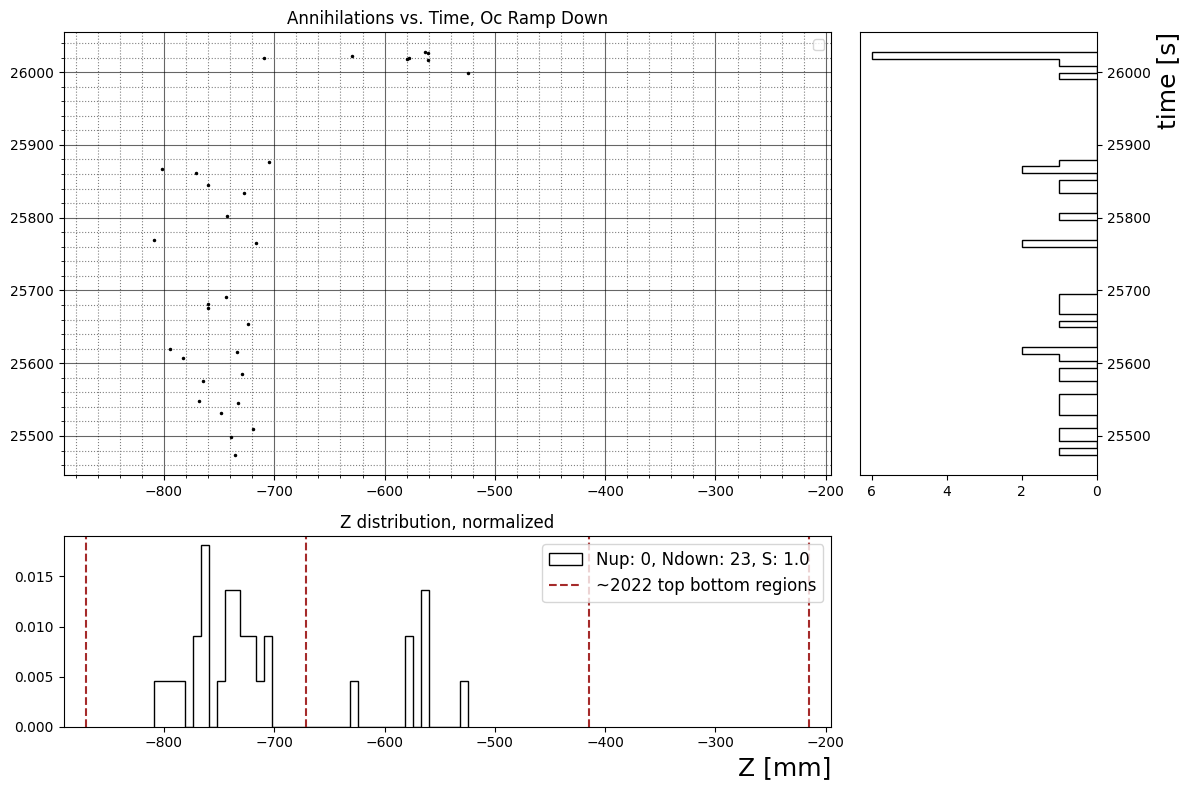

In [14]:
mask = (data["run time"] > Oc_start_rampdown[0]) & (data["run time"] < Oc_stop_rampdown[0])

Nup, Ndown = NupNdown(data, Oc_start_rampdown[0], Oc_stop_rampdown[0], zmin, zmax, zgap_min, zgap_max)
Nup = Nup - bkg_up * (Oc_stop_rampdown[0] - Oc_start_rampdown[0])
Ndown = Ndown - bkg_down * (Oc_stop_rampdown[0] - Oc_start_rampdown[0])

S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.set_title("Annihilations vs. Time, Oc Ramp Down")

ax1.errorbar(data["Z"][mask], data["run time"][mask] , color = "black", marker = ".", markersize = 3, linestyle = "")
# ax1.legend(fontsize = 20)
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

# ax1.axhline(start_mbmf_rampdown0[0], linestyle = "--", label = "mbmf[1]", color = "green")
# ax1.axhline(stop_mbmf_rampdown0[0], linestyle = "--", color = "green")

# ax1.axhline(start_mbmf_rampdown1[0], linestyle = "--", label = "mbmf[2]", color = "blue")
# ax1.axhline(stop_mbmf_rampdown1[0], linestyle = "--", color = "blue")

# ax1.axhline(start_mbmf_rampdown2[0], linestyle = "--", label = "mbmf[3]", color = "red")
# ax1.axhline(stop_mbmf_rampdown2[0], linestyle = "--", color = "red")

# ax1.axhline(start_mbmf_rampdown4[0], linestyle = "--", label = "mbmf[4] Porch", color = "purple")
# ax1.axhline(stop_mbmf_rampdown4[0], linestyle = "--", label = "End Porch", color = "black")
ax1.legend()
ax1.set_xlim(zmin-20,zmax+20)


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(data["Z"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)

counts, bins, _ = ax3.hist(data["run time"][mask], bins = 60, histtype = "step", color = "black", density = False, orientation='horizontal')

#ax3.axhline(timecut, linestyle = "--", color = "black")
#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()

plt.tight_layout()
plt.show()
fig.savefig(f"figures/Oc_RampDown{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# R, phi distributions

In [15]:
def cart2cyl(x, y, z, degrees=False):
    """
    Versione vettoriale (accetta float o array-like) basata su NumPy.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    r = np.hypot(x, y)
    phi = np.arctan2(y, x)                   # (-π, π]
    phi = np.mod(phi, 2 * np.pi)/np.pi       # [0, 2π)

    if degrees:
        phi = np.degrees(phi)

    return phi

In [16]:
data["phi"] = cart2cyl(data["X"], data["Y"], data["Z"])

50 50


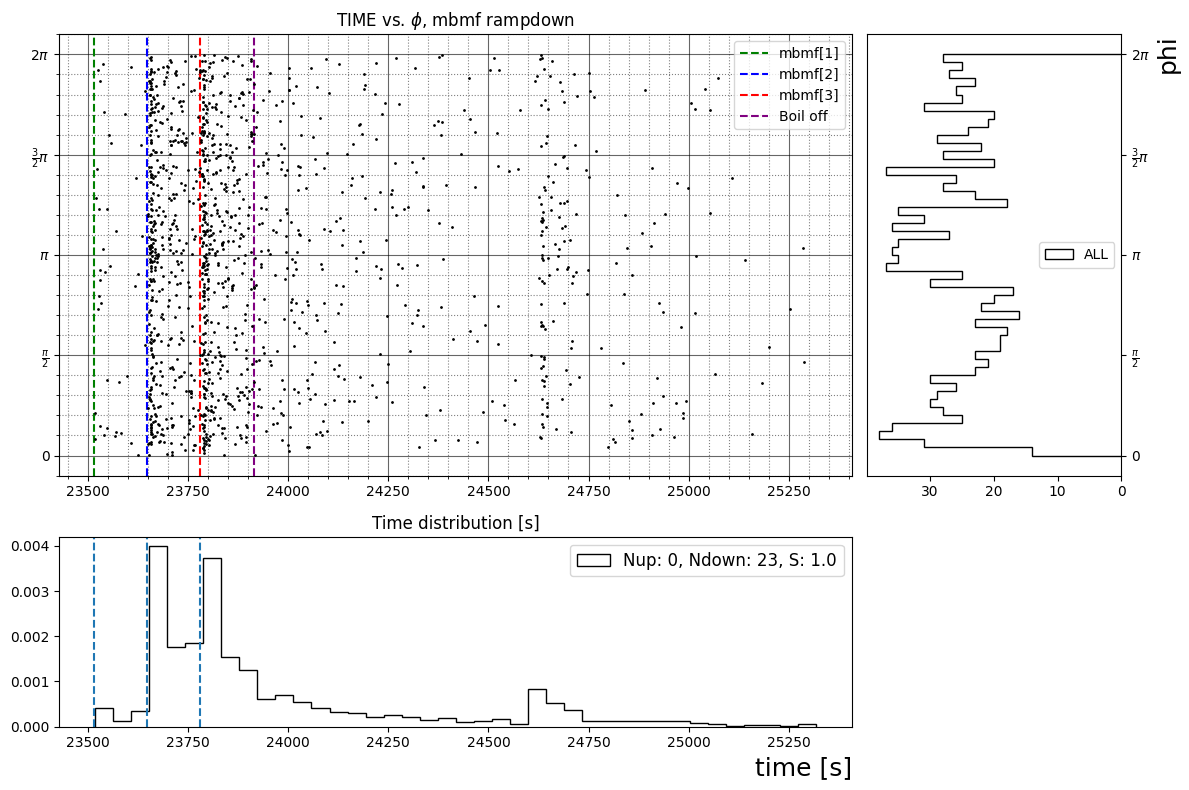

In [17]:
# compute the radius
mask = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < waitForQuasiTrapped_stop2[0])

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occupa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occupa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occupa 1 riga

ax1.errorbar(data["run time"][mask], data["phi"][mask] , color = "black", marker = ".", linestyle = "", markersize = 2)

ax1.set_title(r"TIME vs. $\phi$, mbmf rampdown")
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigiaax1.set_ylim(0, 2)

ax1.set_yticks([0, 0.5, 1, 1.5, 2])
ax1.set_yticklabels([
    "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"
])
ax1.set_ylim(-0.1, 2.1)

#ax1.axvline(start_mbmf_rampdown[0], linestyle = "--", label = "mbmf[0]", color = "orange")
ax1.axvline(start_mbmf_rampdown0[0], linestyle = "--", label = "mbmf[1]", color = "green")
ax1.axvline(start_mbmf_rampdown1[0], linestyle = "--", label = "mbmf[2]", color = "blue")
ax1.axvline(start_mbmf_rampdown2[0], linestyle = "--", label = "mbmf[3]", color = "red")
ax1.axvline(waitForQuasiTrapped_start1[0], linestyle = "--", label = "Boil off", color = "Purple")
ax1.legend()


ax2.hist(data["run time"][mask], bins = binning[0], histtype = "step", color = "black", density = True,  label = f"Nup: {int(Nup)}, Ndown: {int(Ndown)}, S: {S:.2}")
ax2.set_title("Time distribution [s]")
ax2.set_xlabel("time [s]", loc = "right", fontsize = 18)
ax2.legend(fontsize = 12)
#ax2.axvline(start_mbmf_rampdown[0], linestyle = "--")
ax2.axvline(start_mbmf_rampdown0[0], linestyle = "--")
ax2.axvline(start_mbmf_rampdown1[0], linestyle = "--")
ax2.axvline(start_mbmf_rampdown2[0], linestyle = "--")

counts, bins, _ = ax3.hist(data["phi"][mask], bins = 50, range = (0,2),  histtype = "step", color = "black", density = False, orientation='horizontal', label = "ALL")

mask_mbmf1 = (data["run time"] > start_mbmf_rampdown0[0]) & (data["run time"] < start_mbmf_rampdown1[0])
mask_mbmf2 = (data["run time"] > start_mbmf_rampdown1[0]) & (data["run time"] < start_mbmf_rampdown2[0])
mask_mbmf3 = (data["run time"] > start_mbmf_rampdown2[0]) & (data["run time"] < stop_mbmf_rampdown2[0])

#counts, bins, _ = ax3.hist(data["phi"][mask_mbmf1], bins = 25, range = (0,100), histtype = "step", color = "green", density = False, orientation='horizontal', label = "mbmf[1]")
#counts, bins, _ = ax3.hist(data["phi"][mask_mbmf2], bins = 25, range = (0,100), histtype = "step", color = "blue", density = False, orientation='horizontal', label = "mbmf[2]")
#counts, bins, _ = ax3.hist(data["phi"][mask_mbmf3], bins = 25, range = (0,100), histtype = "step", color = "red", density = False, orientation='horizontal', label = "mbmf[3]")
#counts, bins, _ = ax3.hist(data["phi"][mask_mbmf4], bins = 25, range = (0,100), histtype = "step", color = "purple", density = False, orientation='horizontal', label = "mbmf[4]")

print(len(bins[:-1]), len(counts))
ax3.set_ylim(-0.1, 2.1)
ax3.set_ylabel("phi", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")

ax3.set_yticks([0, 0.5, 1, 1.5, 2])
ax3.set_yticklabels([
    "0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$"
])

ax3.invert_xaxis()
ax3.legend()

plt.tight_layout()
plt.show()
fig.savefig(f"figures/TimevsPHI_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Glue the result in the Notebook and retrieve them later

In [18]:
def ScurveExtractor(label, data, tstart, tstop, zcuts):
    
    Nup, Ndown = NupNdown(data, tstart, tstop, zcuts.zmin, zcuts.zmax, zcuts.zgap_min, zcuts.zgap_max)
    Nup        = Nup - bkg_up * (tstop - tstart)
    Ndown      = Ndown - bkg_down * (tstop - tstart)

    if((Nup + Ndown) > 0):
        S = (Ndown - Nup)/(Nup + Ndown)
    else:
        S = np.nan
    
    result = S
    
    if((Nup + Ndown) > 0):
        dResult = np.sqrt(abs(1 - S**2)/(Nup + Ndown))
    else:
        dResult = np.nan

    sb.glue(label, [result, dResult])

    print(label, f"Nup {Nup:.1f}, Ndown {Ndown:.1f}")
    
    return 0

In [19]:
Nup, Ndown = NupNdown(data, start_mbmf_rampdown0[0], stop_mbmf_rampdown2[0], zmin, zmax, zgap_min, zgap_max)
Nup        = Nup - bkg_up * (stop_mbmf_rampdown2[0] - start_mbmf_rampdown0[0])
Ndown      = Ndown - bkg_down * (stop_mbmf_rampdown2[0] - start_mbmf_rampdown0[0])
S = (Ndown - Nup)/(Nup + Ndown)
result = S
dResult = np.sqrt(abs(1 - S**2)/(Nup + Ndown))
sb.glue("my_result", [result, dResult])

###--------------------
ScurveExtractor("ramp1", data, start_mbmf_rampdown0[0], stop_mbmf_rampdown0[0], ZCUTS) # first segment
ScurveExtractor("ramp2", data, start_mbmf_rampdown1[0], stop_mbmf_rampdown1[0], ZCUTS) # second segment
ScurveExtractor("ramp3", data, start_mbmf_rampdown2[0], stop_mbmf_rampdown2[0], ZCUTS) # third segment
ScurveExtractor("ramp4", data, start_mbmf_rampdown3[0], stop_mbmf_rampdown3[0], ZCUTS) # third segment

###--------------------
ScurveExtractor("ramp1pluswait", data, start_mbmf_rampdown0[0], start_mbmf_rampdown1[0], ZCUTS) # first segment
ScurveExtractor("ramp2pluswait", data, start_mbmf_rampdown1[0], start_mbmf_rampdown2[0], ZCUTS) # second segment
ScurveExtractor("ramp3pluswait", data, start_mbmf_rampdown2[0], waitForQuasiTrapped_start1[0], ZCUTS) # third segment
ScurveExtractor("ramp4pluswait", data, start_mbmf_rampdown3[0], waitForQuasiTrapped_start2[0], ZCUTS) # third segment

###--------------------
ScurveExtractor("ramp1onlywait", data, stop_mbmf_rampdown0[0], start_mbmf_rampdown1[0], ZCUTS) # first segment
ScurveExtractor("ramp2onlywait", data, stop_mbmf_rampdown1[0], start_mbmf_rampdown2[0], ZCUTS) # second segment
ScurveExtractor("ramp3onlywait", data, stop_mbmf_rampdown2[0], waitForQuasiTrapped_start1[0], ZCUTS) # third segment
ScurveExtractor("ramp4onlywait", data, stop_mbmf_rampdown3[0], waitForQuasiTrapped_start2[0], ZCUTS) # third segment

ScurveExtractor("boiloff", data, waitForQuasiTrapped_start1[0], waitForQuasiTrapped_stop1[0] , ZCUTS) # boil off
ScurveExtractor("boiloff_2", data, waitForQuasiTrapped_start2[0], waitForQuasiTrapped_stop2[0] , ZCUTS) # boil off

midBoilOff = (waitForQuasiTrapped_start1[0] + waitForQuasiTrapped_stop1[0])/2 - 200
ScurveExtractor("boiloff", data, waitForQuasiTrapped_start1[0], waitForQuasiTrapped_stop1[0] , ZCUTS) # boil off
ScurveExtractor("boiloff_firstpart", data, stop_mbmf_rampdown2[0], midBoilOff , ZCUTS) # boil off
ScurveExtractor("boiloff_lastpart", data, midBoilOff, waitForQuasiTrapped_stop1[0] , ZCUTS) # boil off

# Retrieve all the counts passing selection and save in the notebook
Nup, Ndown = NupNdown(data, mw_cb_start[0], stop_RampAllFinalStep[0], zmin, zmax, zgap_min, zgap_max)
sb.glue("tot_counts", [TOT_RUN_counts.sum(), Nup, Ndown])

ramp1 Nup 1.0, Ndown 5.0


ramp2 Nup 50.0, Ndown 67.0


ramp3 Nup 44.0, Ndown 81.0


ramp4 Nup 2.0, Ndown 29.0


ramp1pluswait Nup 11.9, Ndown 26.9


...

ramp2onlywait Nup 107.9, Ndown 174.9


ramp3onlywait Nup 122.9, Ndown 173.9


ramp4onlywait Nup -0.1, Ndown 70.9


boiloff Nup 101.4, Ndown 153.5


boiloff_2 Nup -0.6, Ndown 56.5
